<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/M101_solo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

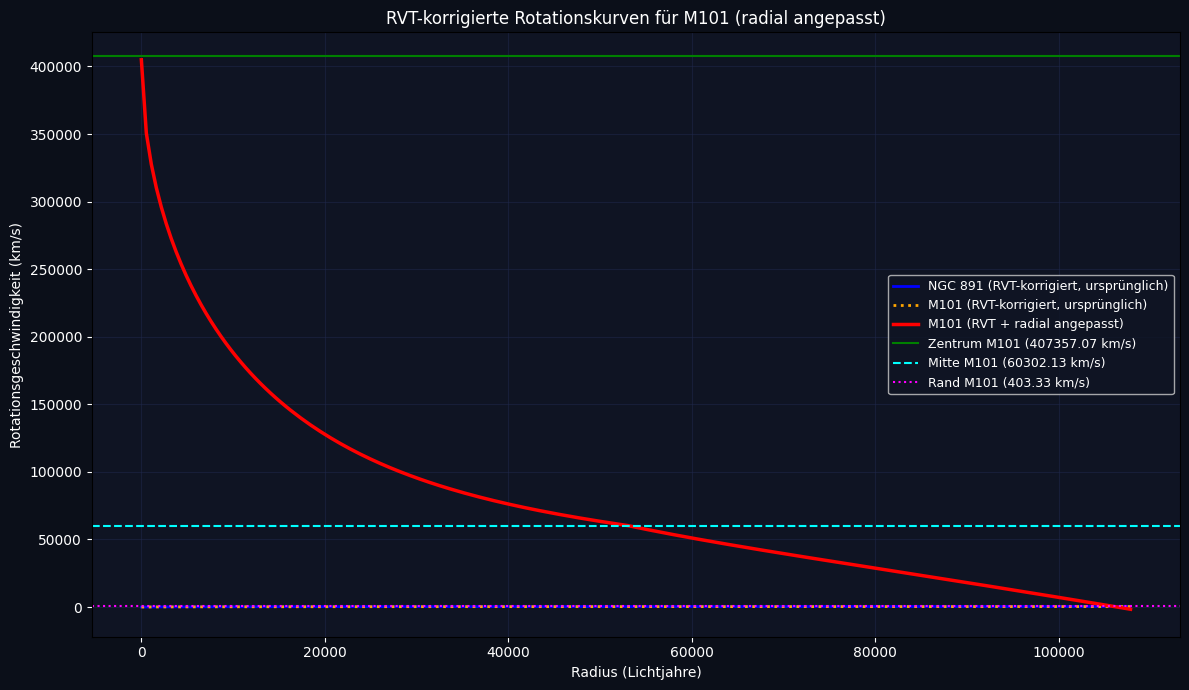

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101
# ==============================================================================
# Gegebene Werte für M101 (radial interpretiert)
v_m101_center = 407357.07  # km/s (Maximalwert im Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mittelwert bei R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Minimalwert ganz außen, R = R_rvt)

# Galaktische Parameter
galaxies = {
    'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000, 'R_rvt': 107817}
}

gamma_m101 = rvt_boost(galaxies['M101']['i'])
gamma_ngc891 = rvt_boost(galaxies['NGC 891']['i'])
R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])

# Skalierte RVT-Kurve für M101 (radial angepasst)
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    # Normierte RVT-Kurve (0 bis 1)
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)  # Fast 0 (Zentrum)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    # Skalierung auf die gegebenen Werte
    # 1. Zentrum (R ≈ 0): v_norm ≈ v_norm_center -> v_center
    # 2. Mitte (R = R_tatsaechlich / 2): v_norm ≈ v_norm_middle -> v_middle
    # 3. Rand (R = R_tatsaechlich): v_norm ≈ v_norm_edge -> v_edge
    # Lineare Interpolation zwischen den Punkten
    if R <= R_tatsaechlich / 2:
        # Skalierung zwischen Zentrum und Mitte
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        # Skalierung zwischen Mitte und Rand
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t

    return v_scaled

# ==============================================================================
# 3. BERECHNUNG DER KURVEN
# ==============================================================================
R_range = np.linspace(1, R_max, 200)

# RVT-korrigierte Kurven (ursprünglich)
v_rvt_ngc891 = [rotation_curve_rvt(r, galaxies['NGC 891']['R_rvt'], gamma_ngc891) for r in R_range]
v_rvt_m101_original = [rotation_curve_rvt(r, galaxies['M101']['R_rvt'], gamma_m101) for r in R_range]

# RVT-korrigierte Kurve für M101 (radial angepasst)
v_rvt_m101_adjusted = [
    rotation_curve_rvt_radial_adjusted(
        r,
        galaxies['M101']['R_rvt'],
        gamma_m101,
        v_m101_center,
        v_m101_middle,
        v_m101_edge
    )
    for r in R_range
]

# ==============================================================================
# 4. PLOT: VERGLEICH DER KURVEN
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# RVT-korrigierte Kurven
ax.plot(R_range, v_rvt_ngc891, color='blue', linewidth=2, label='NGC 891 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_original, color='orange', linewidth=2, linestyle=':', label='M101 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_adjusted, color='red', linewidth=2.5, label='M101 (RVT + radial angepasst)')

# Referenzlinien für M101
ax.axhline(y=v_m101_center, color='green', linestyle='-', linewidth=1.5, label=f'Zentrum M101 ({v_m101_center:.2f} km/s)')
ax.axhline(y=v_m101_middle, color='cyan', linestyle='--', linewidth=1.5, label=f'Mitte M101 ({v_m101_middle:.2f} km/s)')
ax.axhline(y=v_m101_edge, color='magenta', linestyle=':', linewidth=1.5, label=f'Rand M101 ({v_m101_edge:.2f} km/s)')

# Achsen und Titel
ax.set_xlabel('Radius (Lichtjahre)', color='white')
ax.set_ylabel('Rotationsgeschwindigkeit (km/s)', color='white')
ax.set_title('RVT-korrigierte Rotationskurven für M101 (radial angepasst)', color='white', fontsize=12)

# Legende und Grid
ax.legend(facecolor='#0f1423', labelcolor='white', fontsize=9)
ax.grid(True, color='#1f294d', alpha=0.5)
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

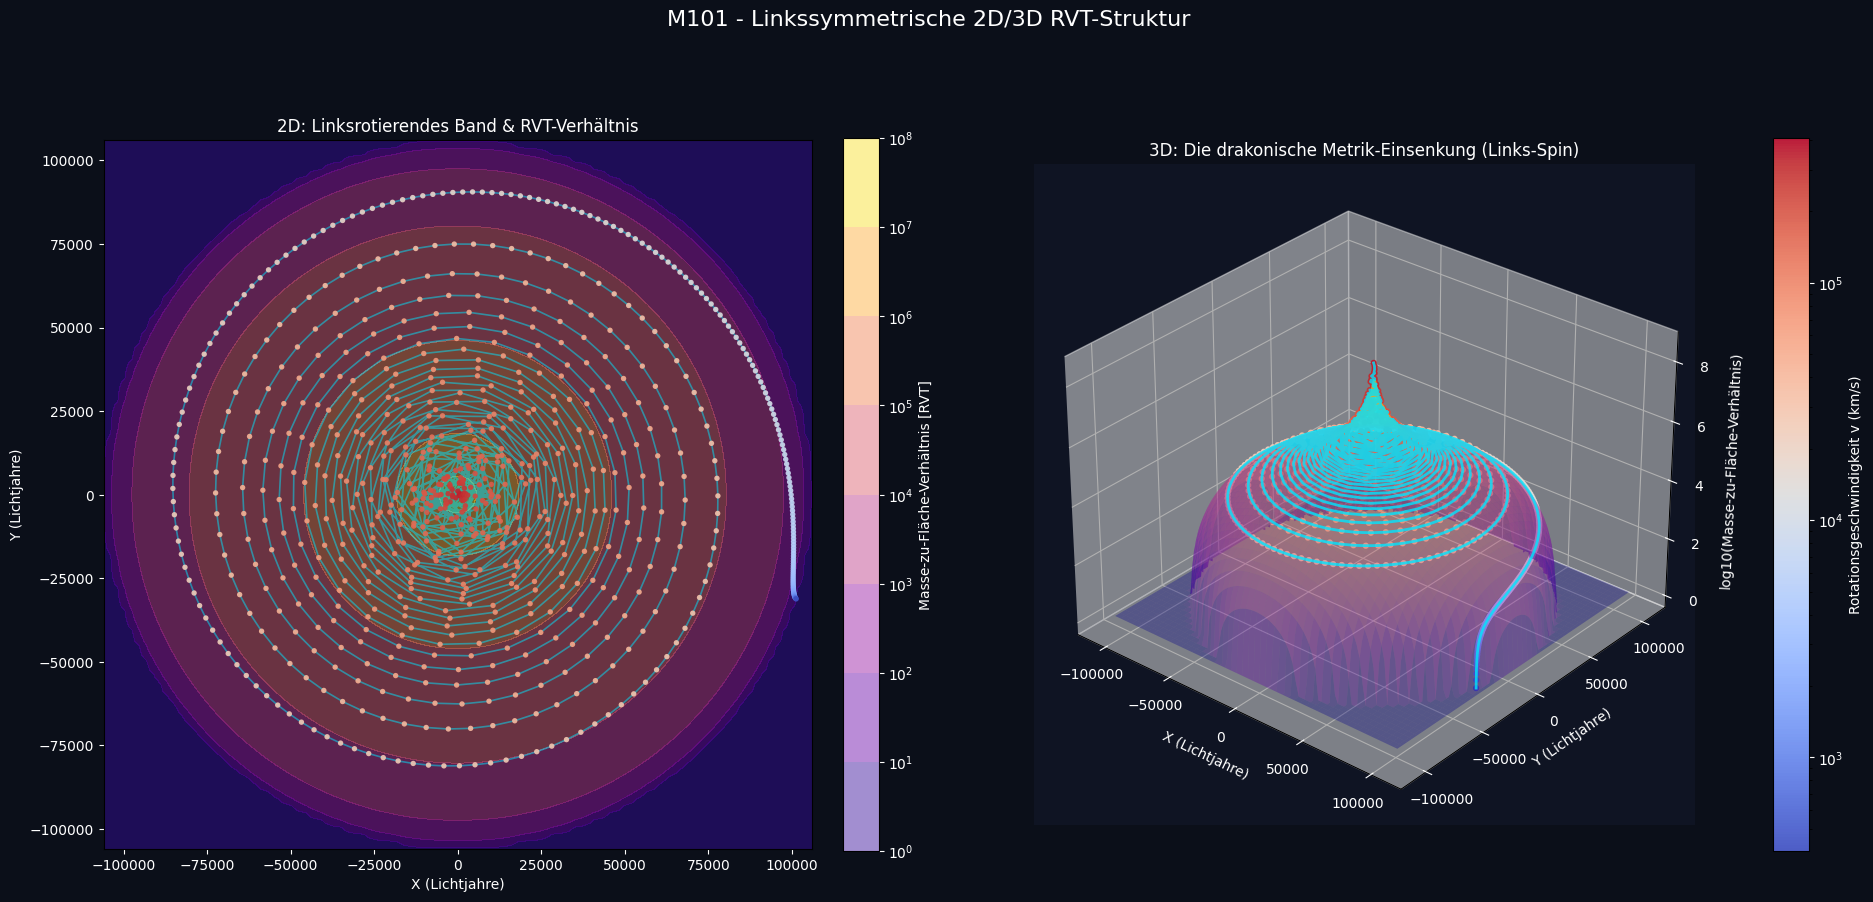

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ==============================================================================
# 1. PARAMETER UND RVT-BASIS DER GALAXIE M101
# ==============================================================================
i_m101 = 18
gamma_m101 = 1 + 0.8 * np.sin(np.radians(i_m101))
R_tatsaechlich_m101_Lj = 106013  # Tatsächlicher Radius unter RVT-Boost

v_m101_center = 407357.07
v_m101_middle = 60302.13
v_m101_edge = 403.33

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    if R <= R_tatsaechlich / 2:
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t
    return v_scaled

# ==============================================================================
# 2. SPIRALEN-STRANG: ERZWVNGENE LINKS-ROTATION (GEKOPPELTES BAND)
# ==============================================================================
R_spiral_Lj = np.linspace(500, R_tatsaechlich_m101_Lj, 800)
v_spiral = np.array([
    rotation_curve_rvt_radial_adjusted(r, R_tatsaechlich_m101_Lj, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge)
    for r in R_spiral_Lj
])
omega = v_spiral / R_spiral_Lj

# Negatives Vorzeichen erzwingt die exakte Links-Scherung im mathematischen System
theta = -np.cumsum(omega * 120.0) / np.max(omega)

X_spiral = R_spiral_Lj * np.cos(theta)
Y_spiral = R_spiral_Lj * np.sin(theta)
Z_spiral_ratio = (v_spiral**2) / R_spiral_Lj

# ==============================================================================
# 3. METRISCHES 2D-GRID FÜR DAS HINTERGRUND-FELD
# ==============================================================================
x = np.linspace(-R_tatsaechlich_m101_Lj, R_tatsaechlich_m101_Lj, 100)
y = np.linspace(-R_tatsaechlich_m101_Lj, R_tatsaechlich_m101_Lj, 100)
X_grid, Y_grid = np.meshgrid(x, y)
R_grid = np.sqrt(X_grid**2 + Y_grid**2)
R_grid = np.clip(R_grid, 1e-3, R_tatsaechlich_m101_Lj)

v_grid = np.zeros_like(R_grid)
for i in range(R_grid.shape[0]):
    for j in range(R_grid.shape[1]):
        v_grid[i, j] = rotation_curve_rvt_radial_adjusted(R_grid[i, j], R_tatsaechlich_m101_Lj, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge)
ratio_grid = (v_grid**2) / R_grid

# ==============================================================================
# 4. DOPPELPANEL-DUALISIERUNG (2D & 3D LINKS-SPIN GEKOPPELT)
# ==============================================================================
fig = plt.figure(figsize=(22, 10), facecolor='#0b0f19')
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

ax1.set_facecolor('#0f1423')
ax2.set_facecolor('#0f1423')

# Panel 1: 2D Kontur + Verbundenes Links-Linienband
contour = ax1.contourf(X_grid, Y_grid, ratio_grid, levels=30, norm=LogNorm(), cmap='plasma', alpha=0.45, zorder=1)
ax1.plot(X_spiral, Y_spiral, color='#00e5ff', linewidth=1.2, alpha=0.5, zorder=2)
spiral_scatter = ax1.scatter(X_spiral, Y_spiral, c=v_spiral, cmap='coolwarm', s=15, norm=LogNorm(vmin=v_m101_edge, vmax=v_m101_center), edgecolors='none', alpha=0.9, zorder=3)

ax1.set_xlim(-R_tatsaechlich_m101_Lj, R_tatsaechlich_m101_Lj)
ax1.set_ylim(-R_tatsaechlich_m101_Lj, R_tatsaechlich_m101_Lj)
ax1.set_aspect('equal')
ax1.tick_params(colors='white')
ax1.set_xlabel('X (Lichtjahre)', color='white')
ax1.set_ylabel('Y (Lichtjahre)', color='white')
ax1.set_title("2D: Linksrotierendes Band & RVT-Verhältnis", color='white')

# Panel 2: 3D Logarithmierte Krümmungstrichter (Links-Spin)
Z_grid_log = np.log10(ratio_grid)
Z_spiral_log = np.log10(Z_spiral_ratio)

surf = ax2.plot_surface(X_grid, Y_grid, Z_grid_log, cmap='plasma', alpha=0.35, rstride=2, cstride=2, linewidth=0, antialiased=True)
ax2.plot(X_spiral, Y_spiral, Z_spiral_log, color='#00e5ff', linewidth=2.0, alpha=0.8, zorder=5)
sc3d = ax2.scatter(X_spiral, Y_spiral, Z_spiral_log, c=v_spiral, cmap='coolwarm', s=12, norm=LogNorm(vmin=v_m101_edge, vmax=v_m101_center), alpha=0.9, zorder=6)

ax2.tick_params(colors='white')
ax2.xaxis.label.set_color('white')
ax2.yaxis.label.set_color('white')
ax2.zaxis.label.set_color('white')
ax2.set_xlabel('X (Lichtjahre)', color='white')
ax2.set_ylabel('Y (Lichtjahre)', color='white')
ax2.set_zlabel('log10(Masse-zu-Fläche-Verhältnis)', color='white')
ax2.set_title("3D: Die drakonische Metrik-Einsenkung (Links-Spin)", color='white')
ax2.view_init(elev=30, azim=-50)

# Farbskalen-Kopplung
cbar1 = fig.colorbar(contour, ax=ax1, pad=0.04, fraction=0.046)
cbar1.set_label('Masse-zu-Fläche-Verhältnis [RVT]', color='white')
cbar1.ax.tick_params(colors='white')

cbar2 = fig.colorbar(sc3d, ax=ax2, pad=0.1, fraction=0.046)
cbar2.set_label('Rotationsgeschwindigkeit v (km/s)', color='white')
cbar2.ax.tick_params(colors='white')

plt.suptitle("M101 - Linkssymmetrische 2D/3D RVT-Struktur", color='white', fontsize=16)
plt.show()